In [4]:
!pip install pymupdf nltk scikit-learn pandas matplotlib wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 29.2 MB/s eta 0:00:00


In [5]:
import fitz
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
from google.colab import files

uploaded = files.upload()

Saving Resume1_ML_Engineer.pdf to Resume1_ML_Engineer.pdf
Saving Resume2_Python_Developer.pdf to Resume2_Python_Developer.pdf
Saving Resume3_Data_Analyst.pdf to Resume3_Data_Analyst.pdf
Saving Resume4_Java_Developer.pdf to Resume4_Java_Developer.pdf
Saving Resume5_Frontend_Developer.pdf to Resume5_Frontend_Developer.pdf


In [7]:
resume_names = []
resume_texts = []

for file_name in uploaded.keys():

    doc = fitz.open(file_name)

    text = ""

    for page in doc:
        text += page.get_text()

    doc.close()

    resume_names.append(file_name)
    resume_texts.append(text)

print("Total Resumes:", len(resume_names))

Total Resumes: 5


In [8]:
for i in range(len(resume_names)):
    print("="*70)
    print("Resume:", resume_names[i])
    print()
    print(resume_texts[i][:1000])

Resume: Resume1_ML_Engineer.pdf

Rahul Sharma
Role: Machine Learning Engineer
Email: sample@example.com
Phone: 9876543210
Education: B.Tech in Computer Science
Skills: Python, Machine Learning, Deep Learning, NLP, Scikit-learn, TensorFlow, Pandas,
NumPy, SQL, Git
Projects: Resume Screening System; Sentiment Analysis
Summary: Motivated software engineer with strong analytical and problem-solving
skills.

Resume: Resume2_Python_Developer.pdf

Priya Reddy
Role: Python Developer
Email: sample@example.com
Phone: 9876543210
Education: B.Tech in Computer Science
Skills: Python, Django, Flask, SQL, Git, HTML, CSS, JavaScript
Projects: Student Management System; E-commerce Website
Summary: Motivated software engineer with strong analytical and problem-solving
skills.

Resume: Resume3_Data_Analyst.pdf

Arjun Kumar
Role: Data Analyst
Email: sample@example.com
Phone: 9876543210
Education: B.Tech in Computer Science
Skills: Excel, SQL, Power BI, Tableau, Python, Pandas
Projects: Sales Dashboard; Bu

In [9]:
job_description = """

Machine Learning Engineer

Required Skills

Python
Machine Learning
Deep Learning
Natural Language Processing
Scikit Learn
TensorFlow
Pandas
NumPy
SQL
Git
Communication Skills
Problem Solving
Data Analysis

"""

In [10]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [11]:
clean_job = clean_text(job_description)

clean_resumes = []

for resume in resume_texts:

    clean_resumes.append(clean_text(resume))

In [12]:
vectorizer = TfidfVectorizer()

vectors = vectorizer.fit_transform([clean_job] + clean_resumes)

print(vectors.shape)

(6, 87)


In [13]:
scores = cosine_similarity(vectors[0:1], vectors[1:]).flatten()

scores

array([0.66141297, 0.15061074, 0.16252886, 0.06225698, 0.07321954])

In [14]:
result = pd.DataFrame({
    "Resume": resume_names,
    "Match Score (%)": (scores * 100).round(2)
})

result = result.sort_values(
    by="Match Score (%)",
    ascending=False
)

result.reset_index(drop=True, inplace=True)

result.index = result.index + 1

result

,Resume,Match Score (%)
1,Resume1_ML_Engineer.pdf,66.14
2,Resume3_Data_Analyst.pdf,16.25
3,Resume2_Python_Developer.pdf,15.06
4,Resume5_Frontend_Developer.pdf,7.32
5,Resume4_Java_Developer.pdf,6.23


In [15]:
required_skills = [

"python",
"machine learning",
"deep learning",
"nlp",
"tensorflow",
"scikit",
"sql",
"pandas",
"numpy",
"git",
"communication",
"problem solving",
"data analysis"

]

In [16]:
missing_skills = []

for resume in clean_resumes:

    missing = []

    for skill in required_skills:

        if skill not in resume:
            missing.append(skill)

    missing_skills.append(", ".join(missing))

In [17]:
result["Missing Skills"] = missing_skills

result

,Resume,Match Score (%),Missing Skills
1,Resume1_ML_Engineer.pdf,66.14,"communication, data analysis"
2,Resume3_Data_Analyst.pdf,16.25,"machine learning, deep learning, nlp, tensorfl..."
3,Resume2_Python_Developer.pdf,15.06,"machine learning, deep learning, nlp, tensorfl..."
4,Resume5_Frontend_Developer.pdf,7.32,"python, machine learning, deep learning, nlp, ..."
5,Resume4_Java_Developer.pdf,6.23,"python, machine learning, deep learning, nlp, ..."


In [18]:
print("="*70)
print("Candidate Ranking")
print("="*70)

for index, row in result.iterrows():

    print(f"\nRank {index}")

    print("Resume :", row["Resume"])

    print("Match Score :", row["Match Score (%)"], "%")

    print("Missing Skills :")

    print(row["Missing Skills"])

    print("-"*70)

Candidate Ranking

Rank 1
Resume : Resume1_ML_Engineer.pdf
Match Score : 66.14 %
Missing Skills :
communication, data analysis
----------------------------------------------------------------------

Rank 2
Resume : Resume3_Data_Analyst.pdf
Match Score : 16.25 %
Missing Skills :
machine learning, deep learning, nlp, tensorflow, scikit, pandas, numpy, communication, data analysis
----------------------------------------------------------------------

Rank 3
Resume : Resume2_Python_Developer.pdf
Match Score : 15.06 %
Missing Skills :
machine learning, deep learning, nlp, tensorflow, scikit, numpy, git, communication, data analysis
----------------------------------------------------------------------

Rank 4
Resume : Resume5_Frontend_Developer.pdf
Match Score : 7.32 %
Missing Skills :
python, machine learning, deep learning, nlp, tensorflow, scikit, pandas, numpy, git, communication, data analysis
----------------------------------------------------------------------

Rank 5
Resume : Resu

In [19]:
best = result.iloc[0]

print("Best Candidate Selected")

print("Resume :", best["Resume"])

print("Score :", best["Match Score (%)"], "%")

Best Candidate Selected
Resume : Resume1_ML_Engineer.pdf
Score : 66.14 %


In [20]:
print(result.head(3))

                         Resume  Match Score (%)  \
1       Resume1_ML_Engineer.pdf            66.14   
2      Resume3_Data_Analyst.pdf            16.25   
3  Resume2_Python_Developer.pdf            15.06   

                                      Missing Skills  
1                       communication, data analysis  
2  machine learning, deep learning, nlp, tensorfl...  
3  machine learning, deep learning, nlp, tensorfl...  


In [21]:
print("Highest Score :", result["Match Score (%)"].max())

print("Lowest Score :", result["Match Score (%)"].min())

print("Average Score :", result["Match Score (%)"].mean())

Highest Score : 66.14
Lowest Score : 6.23
Average Score : 22.200000000000003


In [22]:
result.to_csv("Ranked_Candidates.csv", index=False)

print("Results Saved Successfully")

Results Saved Successfully


In [23]:
from google.colab import files

files.download("Ranked_Candidates.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

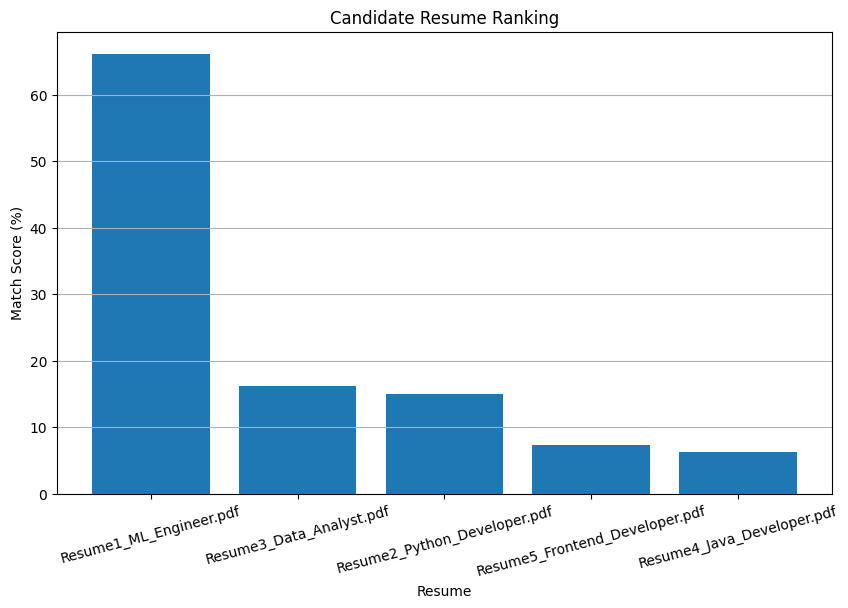

In [24]:
plt.figure(figsize=(10,6))

plt.bar(result["Resume"], result["Match Score (%)"])

plt.title("Candidate Resume Ranking")

plt.xlabel("Resume")

plt.ylabel("Match Score (%)")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.show()

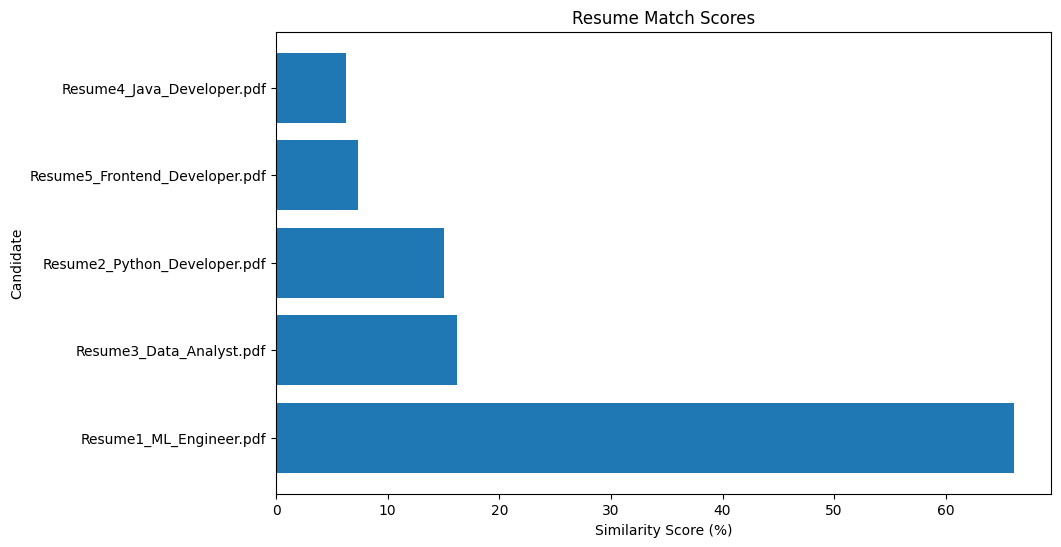

In [25]:
plt.figure(figsize=(10,6))

plt.barh(result["Resume"], result["Match Score (%)"])

plt.title("Resume Match Scores")

plt.xlabel("Similarity Score (%)")

plt.ylabel("Candidate")

plt.show()

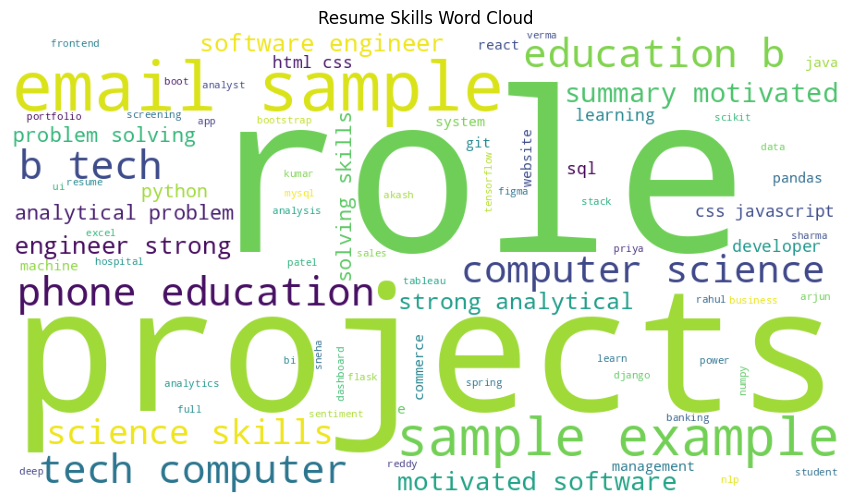

In [26]:
from wordcloud import WordCloud

all_text = " ".join(clean_resumes)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Resume Skills Word Cloud")

plt.show()

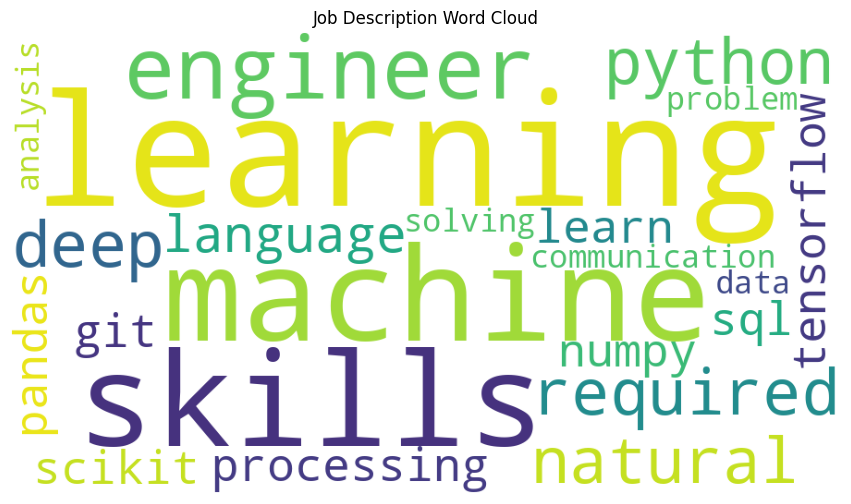

In [27]:
job_cloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(clean_job)

plt.figure(figsize=(12,6))

plt.imshow(job_cloud)

plt.axis("off")

plt.title("Job Description Word Cloud")

plt.show()

In [28]:
best_candidate = result.iloc[0]

print("="*60)
print("RECOMMENDED CANDIDATE")
print("="*60)

print("Resume :", best_candidate["Resume"])
print("Match Score :", best_candidate["Match Score (%)"], "%")
print("Missing Skills :", best_candidate["Missing Skills"])

RECOMMENDED CANDIDATE
Resume : Resume1_ML_Engineer.pdf
Match Score : 66.14 %
Missing Skills : communication, data analysis


In [29]:
print("="*70)
print("AI Resume Screening & Candidate Ranking Summary")
print("="*70)

print("Total Candidates :", len(result))
print("Highest Score :", result["Match Score (%)"].max())
print("Lowest Score :", result["Match Score (%)"].min())
print("Average Score :", round(result["Match Score (%)"].mean(),2))

AI Resume Screening & Candidate Ranking Summary
Total Candidates : 5
Highest Score : 66.14
Lowest Score : 6.23
Average Score : 22.2


In [30]:
result.to_csv("Final_Resume_Ranking_Report.csv", index=False)

print("Final Report Saved Successfully")

Final Report Saved Successfully


In [31]:
from google.colab import files

files.download("Final_Resume_Ranking_Report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
result

,Resume,Match Score (%),Missing Skills
1,Resume1_ML_Engineer.pdf,66.14,"communication, data analysis"
2,Resume3_Data_Analyst.pdf,16.25,"machine learning, deep learning, nlp, tensorfl..."
3,Resume2_Python_Developer.pdf,15.06,"machine learning, deep learning, nlp, tensorfl..."
4,Resume5_Frontend_Developer.pdf,7.32,"python, machine learning, deep learning, nlp, ..."
5,Resume4_Java_Developer.pdf,6.23,"python, machine learning, deep learning, nlp, ..."


In [33]:
print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

print("Features Implemented")
print("✔ PDF Resume Upload")
print("✔ Resume Text Extraction")
print("✔ Text Preprocessing")
print("✔ TF-IDF Vectorization")
print("✔ Cosine Similarity")
print("✔ Resume Ranking")
print("✔ Missing Skills Detection")
print("✔ Candidate Recommendation")
print("✔ Word Cloud")
print("✔ Bar Charts")
print("✔ CSV Report Generation")

PROJECT COMPLETED SUCCESSFULLY
Features Implemented
✔ PDF Resume Upload
✔ Resume Text Extraction
✔ Text Preprocessing
✔ TF-IDF Vectorization
✔ Cosine Similarity
✔ Resume Ranking
✔ Missing Skills Detection
✔ Candidate Recommendation
✔ Word Cloud
✔ Bar Charts
✔ CSV Report Generation
